# 06. Final Model Training

This
notebook
develops
the
final
neural
network
used
throughout
the
remainder
of
the
project.

The class weight is varied one
at
a
time
while all remaining parameters are held constant.Once the optimal value has been identified, it is fixed before progressing to the next optimization stage.

This
process
reduces
unnecessary
experimentation, produces
a
more
reproducible
methodology, and provides
clear
evidence
for the final model configuration presented in this project.

Following
optimization, the
final
neural
network is trained
using
the
selected
parameters
before
being
evaluated
on
the
completely
unseen
2025
Formula
One
season.

# Import Required Libraries

Import
the
libraries
required
to
build, train, and evaluate
the
neural
network.

In [125]:
#Importing Libraries for data processing and collection from previous notebook

import numpy as np

import pandas as pd

from matplotlib import pyplot as plt

import seaborn as sns

import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

#Importing Libraries for the neural network

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.layers import Input

from sklearn.utils.class_weight import compute_class_weight

#Import Accuracy Metrics

from sklearn.metrics import f1_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


# Load Processed Data

Load
the
processed
training and validation
datasets
generated in the
previous
notebook.

Since
all
preprocessing
has
already
been
completed, the
data
can
now
be
passed
directly
into
the
neural
network.

In [126]:
#Import processed data

X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")

preprocessor = joblib.load("../models/preprocessor.pkl")

numerical_features = joblib.load(
    "../data/processed/numerical_features.pkl"
)

categorical_features = joblib.load(
    "../data/processed/categorical_features.pkl"
)

train_df = joblib.load("../data/processed/train_df.pkl")
val_df = joblib.load("../data/processed/val_df.pkl")
test_df = joblib.load("../data/processed/test_df.pkl")

In [127]:
#Unpack training and validation datasets

# X_train = X_train.item()
# X_val = X_val.item()

# Build Neural Network

To
simplify
experimentation, the
neural
network
architecture is defined as a
reusable
function.

This
allows
different
hyperparameter
combinations
to
be
evaluated
without
rewriting
the
model
for every experiment, improving both readability and reproducibility.

In [128]:
def build_model(

        input_dim,

):
    model = Sequential([

        Input(shape=(input_dim,)),

        Dense(128),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dropout(0.3),

        Dense(64),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dropout(0.3),

        Dense(32),

        BatchNormalization(),

        tf.keras.layers.ReLU(),

        Dense(1, activation="sigmoid")

    ])

    optimizer = tf.keras.optimizers.Adam(

        learning_rate=0.001

    )

    loss = tf.keras.losses.BinaryFocalCrossentropy(

        gamma=2

    )

    model.compile(

        optimizer=optimizer,

        loss=loss,

        metrics=["accuracy"]

    )

    return model

# Shared Training Configuration

Each
experiment
uses
the
same
callback
strategy
to
improve
training
stability.

Early
stopping
prevents
unnecessary
training
once
validation
performance
stops
improving,
while an adaptive learning rate allows the optimizer to make progressively smaller updates as convergence is approached.

A
fresh
set
of
callbacks is created
for every experiment to prevent internal callback states from being shared between different models during hyperparameter optimization.

In [129]:
def get_callbacks():

    #EarlyStopping (stops training automatically when the model stops improving)
    #use a patience value of 15-30 as the class imbalance is going to create a lot of fluctuation in val loss... we have restore_best_weights as well so we should be fine!

    early_stop = EarlyStopping(

    monitor="val_loss",

    patience=12,

    restore_best_weights=True,

    verbose=1

    )

    #Reducing the learning rate if performance plateaus
    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=5,

        cooldown=1,

        min_lr=1e-6,

        verbose=1

    )

    return [

        early_stop,

        reduce_lr

    ]

# Model Evaluation Functions

Rather
than
rewriting
the
complete
training
procedure
for every optimisation stage, a single reusable function is used.

This
function
trains
a
neural
network
using
a
supplied
collection
of
hyperparameters
before
evaluating
performance
on
the
validation
dataset.

The
optimal
decision
threshold is determined
automatically
by
maximising
the
F1-score
of
the
pit-stop class.

In [130]:
def evaluate_configuration(

        X_train,

        y_train,

        X_val,

        y_val,

        epochs,

        class_weight_0,

        class_weight_1,

        batch_size=64,

        set_threshold=0.50,

        return_model=True

):
    #Get callbacks
    early_stop, reduce_lr = get_callbacks()

    #Build model
    model = build_model(

        X_train.shape[1],

    )

    #Train
    history = model.fit(

        X_train,

        y_train,

        validation_data=(X_val, y_val),

        epochs=epochs,  #will be 60 epochs for optimization stages, will be 100-150 for the final test data eval.

        batch_size=batch_size,

        verbose=0,

        callbacks=[

            early_stop,

            reduce_lr

        ],

        class_weight={

            0: class_weight_0,

            1: class_weight_1

        }

    )

    #Save epoch value
    epochs_trained = len(history.history["loss"])

    #Validation probabilities
    y_prob = model.predict(X_val, verbose=0).flatten()

    #Threshold optimisation
    if set_threshold:

        best_threshold = set_threshold

        predictions = (y_prob >= best_threshold).astype(int)

        best_precision = precision_score(
            y_val,
            predictions,
            zero_division=0
        )

        best_recall = recall_score(
            y_val,
            predictions,
            zero_division=0
        )

        best_f1 = f1_score(
            y_val,
            predictions,
            zero_division=0
        )

    else:

        thresholds = np.arange(0.10, 0.991, 0.005)

        best_threshold = 0.50
        best_precision = 0
        best_recall = 0
        best_f1 = 0

        for threshold in thresholds:

            predictions = (y_prob >= threshold).astype(int)

            precision = precision_score(
                y_val,
                predictions,
                zero_division=0
            )

            recall = recall_score(
                y_val,
                predictions,
                zero_division=0
            )

            f1 = f1_score(
                y_val,
                predictions,
                zero_division=0
            )

            if f1 > best_f1:

                best_threshold = threshold
                best_precision = precision
                best_recall = recall
                best_f1 = f1


    #Return results
    results = {

        "Epochs": epochs_trained,

        "Precision": best_precision,

        "Recall": best_recall,

        "Threshold": best_threshold,

        "F1": best_f1

    }

    if return_model:
        results["Model"] = model

        results["History"] = history

    return results

### Shared Plotting Function

The
following
helper
function is used
throughout
each
optimisation
stage
to
visualise
model
performance and simplify
comparison
between
experiments.

In [131]:
def plot_metric(

        dataframe,

        parameter,

        metric,

        title

):
    plt.figure(figsize=(8, 5))

    plt.plot(

        dataframe[parameter],

        dataframe[metric],

        marker="o"

    )

    plt.grid(alpha=0.3)

    plt.xlabel(parameter)

    plt.ylabel(metric)

    plt.title(title)

    plt.show()

## Evaluating Feature Importance with Random Forest

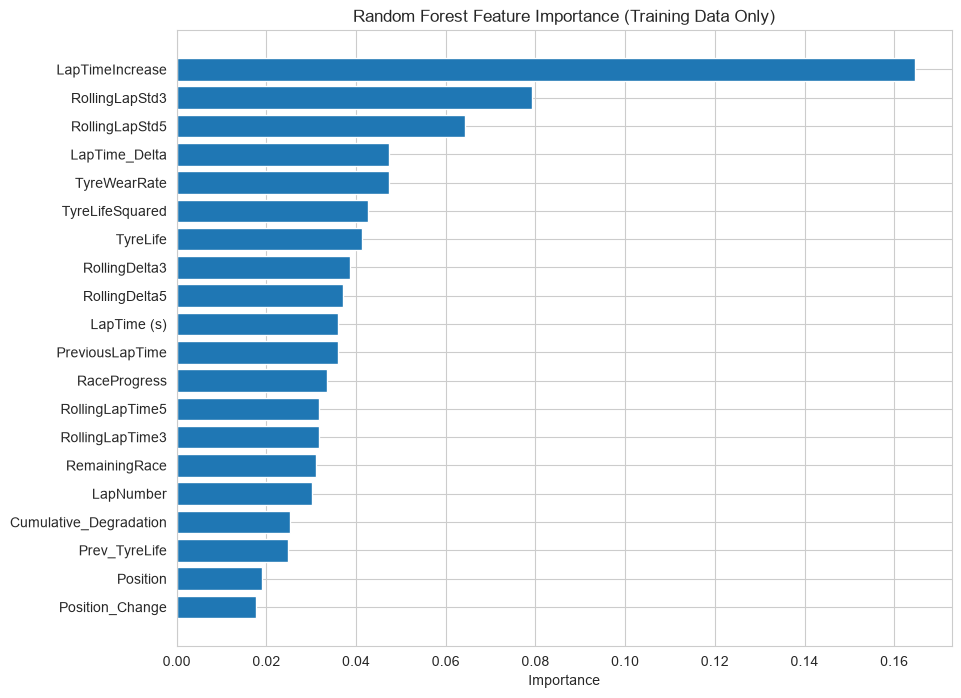

In [132]:
#Evaluating FEATURE IMPORTANCE

from sklearn.ensemble import RandomForestClassifier

# Training features only
rf_X_train = train_df.drop(columns=["PitNextLap"])

# Training target only
rf_y_train = train_df["PitNextLap"]

#one-hot encode categorical variables
rf_X_train = pd.get_dummies(
    rf_X_train,
    drop_first=True
)

#Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=1717,
    n_jobs=-1
)

rf.fit(rf_X_train, rf_y_train)

#Get feature importances
importance = pd.DataFrame({

    "Feature": rf_X_train.columns,

    "Importance": rf.feature_importances_

})

#Sort
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

#Plot
plt.figure(figsize=(10,8))

top20 = importance.head(20)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance (Training Data Only)")

plt.show()

### Baseline Model

Before any weight optimization, the current neural network was first evaluated using the complete feature set, providing a reference point.

In [133]:
#Use auto class weights for baseline

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.float64(0.0): np.float64(0.5160870332774296), np.float64(1.0): np.float64(16.040466392318244)}


In [134]:
baseline = evaluate_configuration(

    X_train,

    y_train,

    X_val,

    y_val,

    epochs=60,

    class_weight_0 = class_weights[0],

    class_weight_1 = class_weights[1],

    batch_size=64,

    return_model=True,

    set_threshold=0.50

)

base_model = baseline["Model"]
base_history = baseline["History"]
base_best_threshold = float(baseline["Threshold"])

print(base_best_threshold, baseline['F1'], baseline['Precision'], baseline['Recall'])


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 35: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 25.
0.5 0.40301536677297767 0.25788497217068646 0.9217506631299734


### Class Weight + Threshold Optimisation

The dataset used throughout this project is highly imbalanced, with pit stops representing only a small proportion of the total observations.

Without compensation, the neural network naturally favours the majority "No Pit" class, resulting in poor identification of pit-stop laps.

To address this issue, several class weight combinations are evaluated while keeping every other training parameter constant.

The optimal weighting is selected according to the F1-score of the pit-stop class measured on the validation dataset.

In [ ]:
candidate_weights = [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    12,
    14,
    16,
    18,
    20
]

results = []

for weight in candidate_weights:

    print(f"Testing class weight {weight}")

    output = evaluate_configuration(

        X_train,
        y_train,
        X_val,
        y_val,

        epochs = 60,

        class_weight_0=1,

        class_weight_1=weight,

        batch_size=64,

        return_model=False,

        set_threshold=False

    )

    results.append({

    "Class Weight":weight,

    "Epochs":output["Epochs"],

    "Precision":output["Precision"],

    "Recall":output["Recall"],

    "Threshold":output["Threshold"],

    "F1":output["F1"]

    })

Testing class weight 2


In [162]:
#Display results
results = pd.DataFrame(results)

results = results.sort_values(
    by="F1",
    ascending=False
)

results

,Class Weight,Epochs,Precision,Recall,Threshold,F1
2,4,24,0.736906,0.802387,0.600,0.768254
1,3,22,0.763469,0.770557,0.620,0.766997
7,9,28,0.773842,0.753316,0.700,0.763441
3,5,25,0.747126,0.775862,0.615,0.761223
5,7,27,0.711217,0.790451,0.625,0.748744
10,14,26,0.761317,0.736074,0.710,0.748483
0,2,28,0.758197,0.736074,0.580,0.746972
6,8,23,0.727735,0.758621,0.670,0.742857
4,6,18,0.735178,0.740053,0.635,0.737607
9,12,18,0.700000,0.770557,0.655,0.733586


In [168]:
#Save best class weight
best_result = results.iloc[0]

best_class_weight = int(best_result["Class Weight"])
best_threshold = float(best_result["Threshold"])

print(f"Best class weight : {best_class_weight}")
print(f"Best threshold    : {best_threshold:.3f}")
print(f"Validation F1     : {best_result['F1']:.3f}")

Best class weight : 4
Best threshold    : 0.600
Validation F1     : 0.768


## Train updated model

In [169]:
#Train updated model with class weight

updated_results = evaluate_configuration(

    X_train,

    y_train,

    X_val,

    y_val,

    epochs=60,

    class_weight_0 = 1,

    class_weight_1 = best_class_weight,

    batch_size=64,

    return_model=True,

    set_threshold=False

)

model = updated_results["Model"]
history = updated_results["History"]
best_threshold = float(updated_results["Threshold"])

print(best_threshold, updated_results['F1'], updated_results['Precision'], updated_results['Recall'])


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 7.
0.6200000000000004 0.7391594396264176 0.7436241610738255 0.7347480106100795


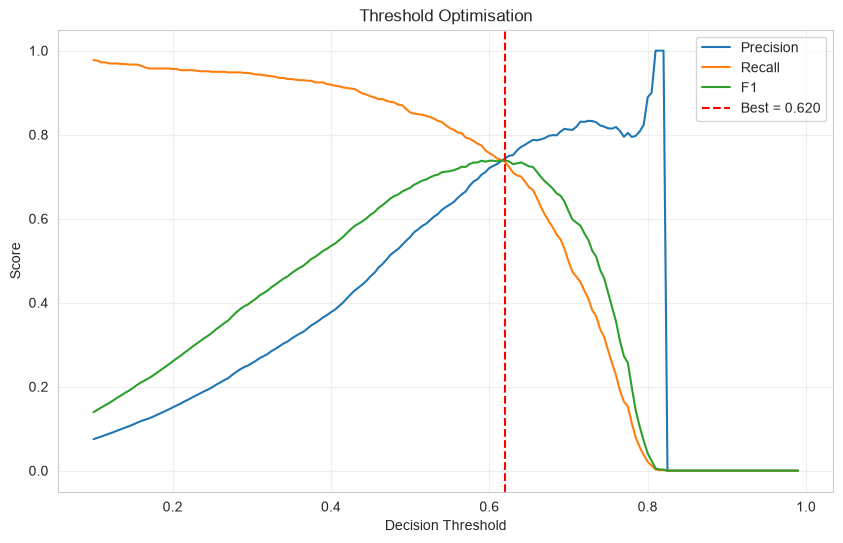

In [170]:
#Make a Threshold Plot

y_val_prob = model.predict(X_val, verbose=0).flatten()

thresholds = np.arange(0.10, 0.991, 0.005)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    predictions = (y_val_prob >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_val, predictions, zero_division=0)
    )

    recall_scores.append(
        recall_score(y_val, predictions, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_val, predictions, zero_division=0)
    )

#Create plot
plt.figure(figsize=(10,6))

plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, f1_scores, label="F1")

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best = {best_threshold:.3f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimisation")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

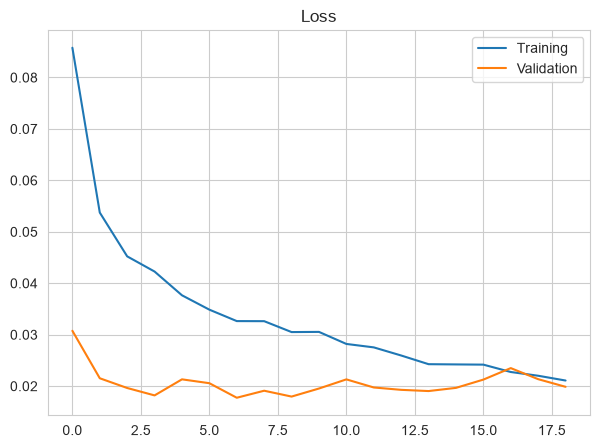

In [171]:
#Plot loss curve

plt.figure(figsize=(7,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.title("Loss")

plt.show()

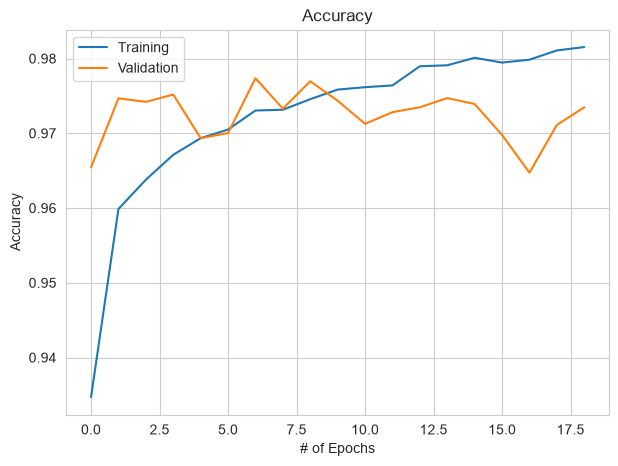

In [172]:
#Plot accuracy curve

plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Training","Validation"])

plt.title("Accuracy")

plt.xlabel("# of Epochs")
plt.ylabel("Accuracy")

plt.show()

# Final Evaluation on the 2025 Formula One Season

Following the completion of class weight and threshold optimization, the final neural network was evaluated on the unseen 2025 Formula One season, providing an unbiased assessment of its ability to generalise to future races.

In [173]:
#Create final training data (2022-24) by combining previous training (2022-23) and validation (2024) data

combined_train = pd.concat(

    [

        train_df,

        val_df

    ],

    ignore_index=True

)

In [174]:
#Rebuild the inputs

X_train_final = combined_train.drop(

    "PitNextLap",

    axis=1

)

y_train_final = combined_train["PitNextLap"].values

In [175]:
#Re-fit processor

X_train_final = preprocessor.fit_transform(

    X_train_final

)

X_test_final = preprocessor.transform(

    test_df.drop(

        "PitNextLap",

        axis=1

    )

)

y_test_final = test_df["PitNextLap"].values

# Evaluating 2025 season using baseline model

In [176]:
#Evaluate baseline model

base_results = evaluate_configuration(

    X_train_final,

    y_train_final,

    X_test_final,

    y_test_final,

    epochs = 150,

    class_weight_0 = class_weights[0],

    class_weight_1 = class_weights[1],

    set_threshold=0.50,

    return_model=True

)

base_model = base_results["Model"]

base_history = base_results["History"]


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 11.


In [177]:
#Test prediction

base_probabilities = base_model.predict(

    X_test_final,

    verbose=0

).flatten()

base_predictions = (

    base_probabilities >= 0.50

).astype(int)

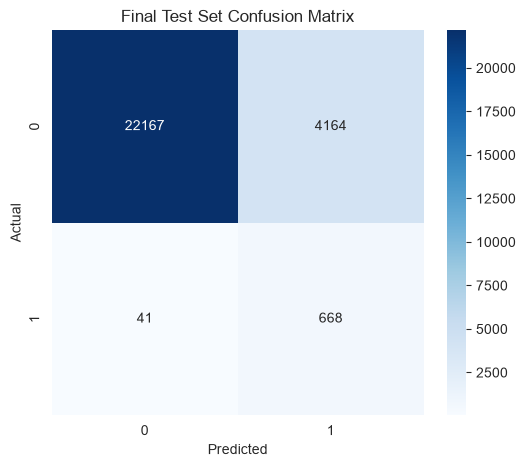

In [178]:
#Confusion matrix

#Confusion Matrix

cm = confusion_matrix(

    y_test_final,

    base_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Final Test Set Confusion Matrix")

plt.show()

In [179]:
#Classification Report

#Classification Report

print(
    classification_report(
        y_test_final,
        base_predictions
    )
)

              precision    recall  f1-score   support

         0.0       1.00      0.84      0.91     26331
         1.0       0.14      0.94      0.24       709

    accuracy                           0.84     27040
   macro avg       0.57      0.89      0.58     27040
weighted avg       0.98      0.84      0.90     27040



# Training the optimized model

In [180]:
#Train the final model

final_results = evaluate_configuration(

    X_train_final,

    y_train_final,

    X_test_final,

    y_test_final,

    epochs = 150,

    class_weight_0 = 1,

    class_weight_1 = best_class_weight,

    set_threshold=best_threshold,

    return_model=True

)


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 5.


In [181]:
#Extract results

final_model = final_results["Model"]

final_history = final_results["History"]

In [182]:
#Test prediction

test_probabilities = final_model.predict(

    X_test_final,

    verbose=0

).flatten()

test_predictions = (

    test_probabilities >= best_threshold

).astype(int)

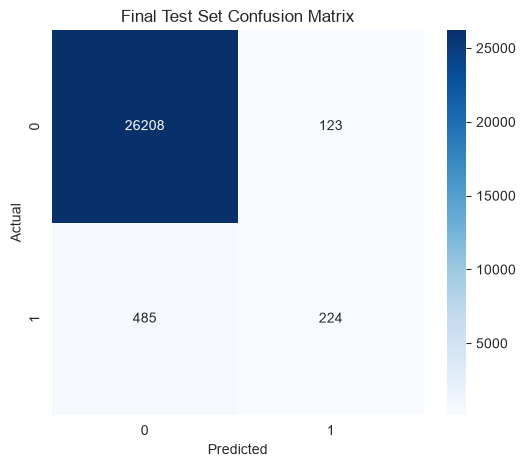

In [183]:
#Confusion Matrix

cm = confusion_matrix(

    y_test_final,

    test_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Final Test Set Confusion Matrix")

plt.show()

In [184]:
#Classification Report

print(
    classification_report(
        y_test_final,
        test_predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     26331
         1.0       0.65      0.32      0.42       709

    accuracy                           0.98     27040
   macro avg       0.81      0.66      0.71     27040
weighted avg       0.97      0.98      0.97     27040



The final model achieved a precision of ___ and a recall of ___ for pit-stop prediction, indicating that when the model recommends a pit stop, it is correct approximately ___ of the time. In a Formula One race strategy context, higher precision is particularly valuable because an unnecessary pit stop recommendation can result in a substantial loss of track position and race time, whereas a missed recommendation may still allow the team to continue on the current strategy until the next lap. Consequently, the model was intentionally optimized to favor more reliable pit-stop recommendations over maximizing the number of predicted pit stops.

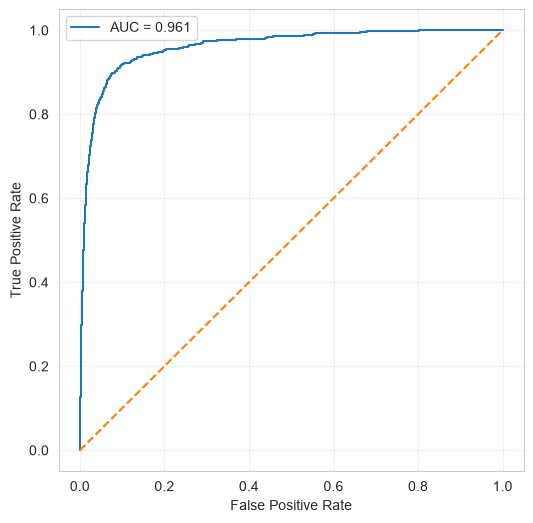

In [185]:
#ROC Curve

fpr, tpr, _ = roc_curve(

    y_test_final,

    test_probabilities

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

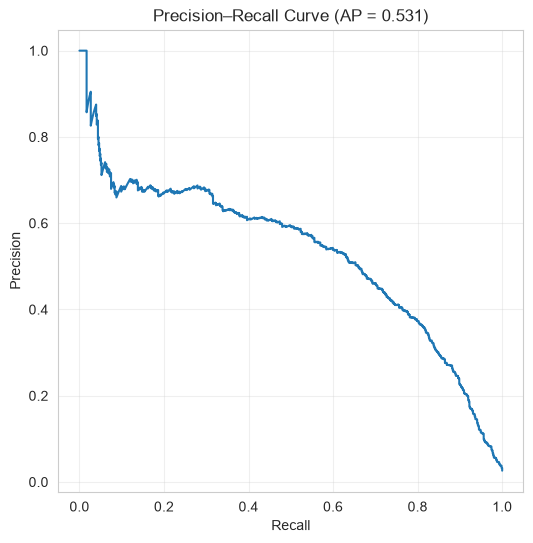

In [186]:
#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(

    y_test_final,

    test_probabilities

)

ap = average_precision_score(

    y_test_final,

    test_probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    recall,

    precision

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(

    f"Precision–Recall Curve (AP = {ap:.3f})"

)

plt.grid(alpha=0.3)

plt.show()

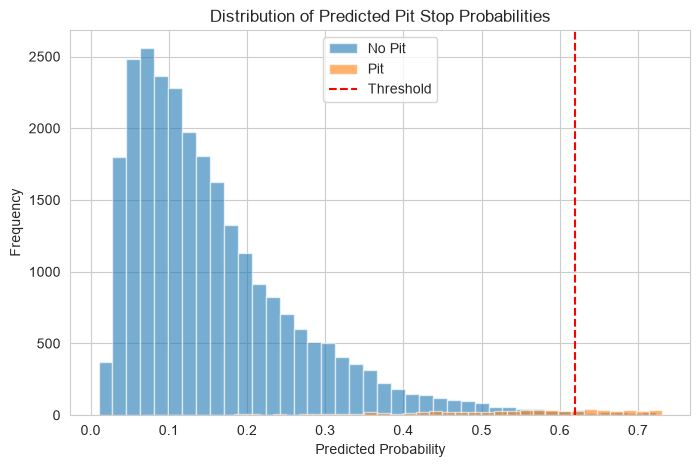

In [187]:
# Result graphs

# Histogram of predicted probabilities split by class

test_results = test_df.copy()

test_results["PitProbability"] = test_probabilities.flatten()

plt.figure(figsize=(8,5))

plt.hist(
    test_results.loc[test_results["PitNextLap"] == 0, "PitProbability"],
    bins=40,
    alpha=0.6,
    label="No Pit"
)

plt.hist(
    test_results.loc[test_results["PitNextLap"] == 1, "PitProbability"],
    bins=40,
    alpha=0.6,
    label="Pit"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Pit Stop Probabilities")
plt.legend()
plt.show()

# Creating Pit Probability Ploting Function

In [188]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_pit_probability(
    test_df,
    y_prob,
    year,
    race,
    driver,
    figsize=(15,6)
):

    # --------------------------------------------------------
    # Use globally-computed threshold
    # --------------------------------------------------------

    threshold = best_threshold

    # --------------------------------------------------------
    # Prepare dataframe
    # --------------------------------------------------------

    results = test_df.copy()
    results["PitProbability"] = y_prob.flatten()

    example = results[
        (results["Year"] == year) &
        (results["Race"] == race) &
        (results["Driver"] == driver)
    ].sort_values("LapNumber")

    if example.empty:
        print("No matching race found.")
        return

    # --------------------------------------------------------
    # FIA tyre colours
    # --------------------------------------------------------

    compound_colors = {

        "SOFT": "#E10600",
        "MEDIUM": "#FFD800",
        "HARD": "#888888",
        "INTERMEDIATE": "#43B02A",
        "WET": "#0067B8"

    }

    fig, ax = plt.subplots(figsize=figsize)

    laps = example["LapNumber"].values
    compounds = example["Compound"].values

    # ========================================================
    # Shade tyre stints
    # ========================================================

    start = laps[0] - 0.5

    for i in range(1, len(example)):

        if compounds[i] != compounds[i-1]:

            end = laps[i] - 0.5

            ax.axvspan(
                start,
                end,
                color=compound_colors.get(compounds[i-1], "lightgray"),
                alpha=0.18,
                linewidth=0,
                zorder=0
            )

            start = end

    ax.axvspan(
        start,
        laps[-1] + 0.5,
        color=compound_colors.get(compounds[-1], "lightgray"),
        alpha=0.18,
        linewidth=0,
        zorder=0
    )

    # ========================================================
    # Probability curve
    # ========================================================

    ax.plot(
        example["LapNumber"],
        example["PitProbability"],
        color="black",
        linewidth=3.25,
        zorder=5
    )

    # Plot individual lap markers
    ax.plot(
        example["LapNumber"],
        example["PitProbability"],
        "-o",
        color="black",
        linewidth=2.8,
        markersize=4,
        zorder=5
    )

    # ========================================================
    # Threshold
    # ========================================================

    ax.axhline(
        threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        zorder=2
    )

    # ========================================================
    # Model recommendations
    # ========================================================

    recommendations = example[
        example["PitProbability"] >= threshold
    ]

    ax.scatter(
        recommendations["LapNumber"] + 1,
        recommendations["PitProbability"],
        s=90,
        color="red",
        edgecolor="black",
        linewidth=0.8,
        zorder=7
    )

    # ========================================================
    # Actual pit stops
    # ========================================================

    pit_laps = example.loc[
        example["PitNextLap"] == 1,
        "LapNumber"
    ] + 1

    for lap in pit_laps:

        # Vertical line

        ax.axvline(
            lap,
            color="green",
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            zorder=3
        )

        # Green star

        ax.scatter(
            lap,
            0.985,
            marker="*",
            s=260,
            color="limegreen",
            edgecolor="black",
            linewidth=1,
            zorder=8
        )

    # ========================================================
    # Tyre Life
    # ========================================================

    ax2 = ax.twinx()

    ax2.plot(
        example["LapNumber"],
        example["TyreLife"],
        color="royalblue",
        linestyle="--",
        linewidth=2.3,
        alpha=0.9,
        zorder=4
    )

    ax2.set_ylabel(
        "Tyre Life (laps)",
        fontsize=12,
        color="royalblue"
    )

    ax2.tick_params(
        axis="y",
        colors="royalblue"
    )

    # ========================================================
    # Labels
    # ========================================================

    ax.set_title(
        f"{driver} | {race} ({year})",
        fontsize=17,
        weight="bold"
    )

    ax.set_xlabel("Lap Number", fontsize=12)

    ax.set_ylabel(
        "Predicted Pit Stop Probability",
        fontsize=12
    )

    ax.set_ylim(0,1.02)

    ax.set_xlim(
        laps.min()-0.5,
        laps.max()+0.5
    )

    ax.grid(alpha=0.25)

    # ========================================================
    # Legend
    # ========================================================

    legend_items = [

        Line2D([0],[0],
               color="black",
               lw=3,
               label="Predicted Probability"),

        Line2D([0],[0],
               color="royalblue",
               lw=2,
               linestyle="--",
               label="Tyre Life"),

        Line2D([0],[0],
               color="red",
               lw=2,
               linestyle="--",
               label=f"Decision Threshold ({threshold:.2f})"),

        Line2D([0],[0],
               marker='o',
               color='w',
               markerfacecolor='red',
               markeredgecolor='black',
               markersize=8,
               label="Model Recommendation"),

        Line2D([0],[0],
               marker='*',
               color='w',
               markerfacecolor='limegreen',
               markeredgecolor='black',
               markersize=14,
               label="Actual Pit"),

        Patch(facecolor="#E10600",
              alpha=0.18,
              label="Soft"),

        Patch(facecolor="#FFD800",
              alpha=0.18,
              label="Medium"),

        Patch(facecolor="#888888",
              alpha=0.18,
              label="Hard"),

        Patch(facecolor="#43B02A",
              alpha=0.18,
              label="Intermediate"),

        Patch(facecolor="#0067B8",
              alpha=0.18,
              label="Wet")

    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        ncol=2,
        fontsize=10,
        frameon=True
    )

    plt.tight_layout()
    plt.show()

# Example Gallery from 2025

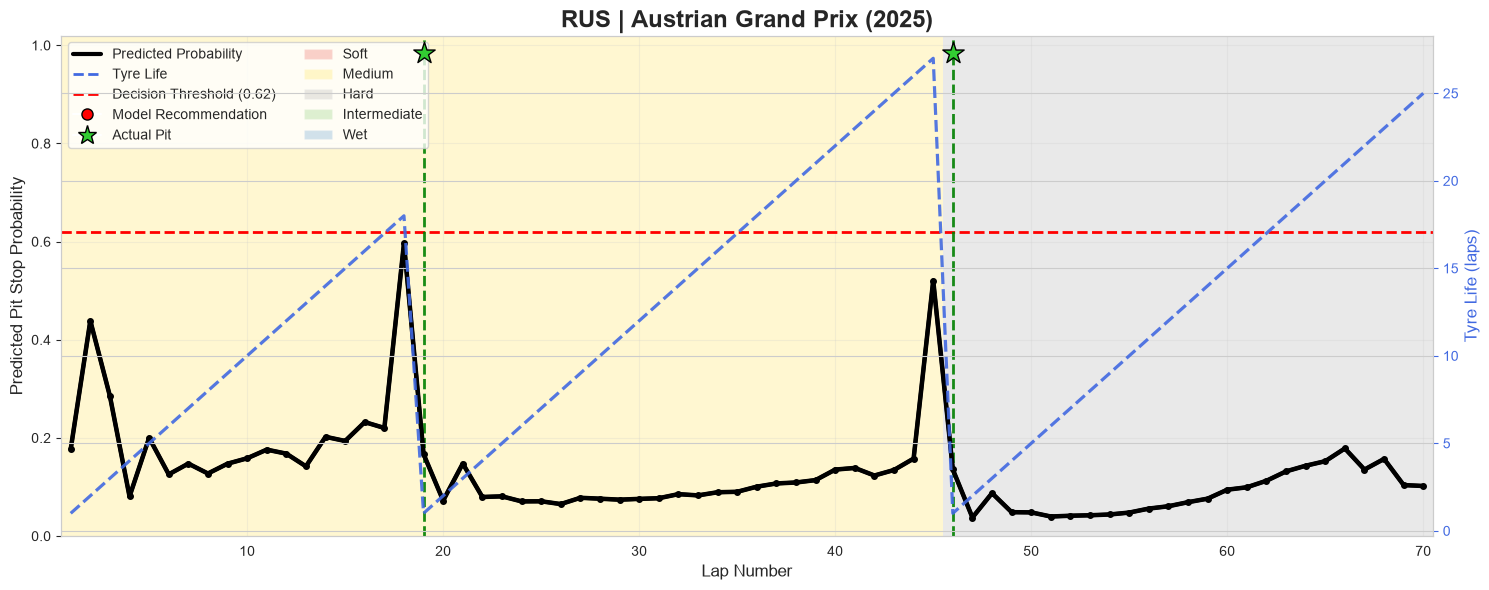

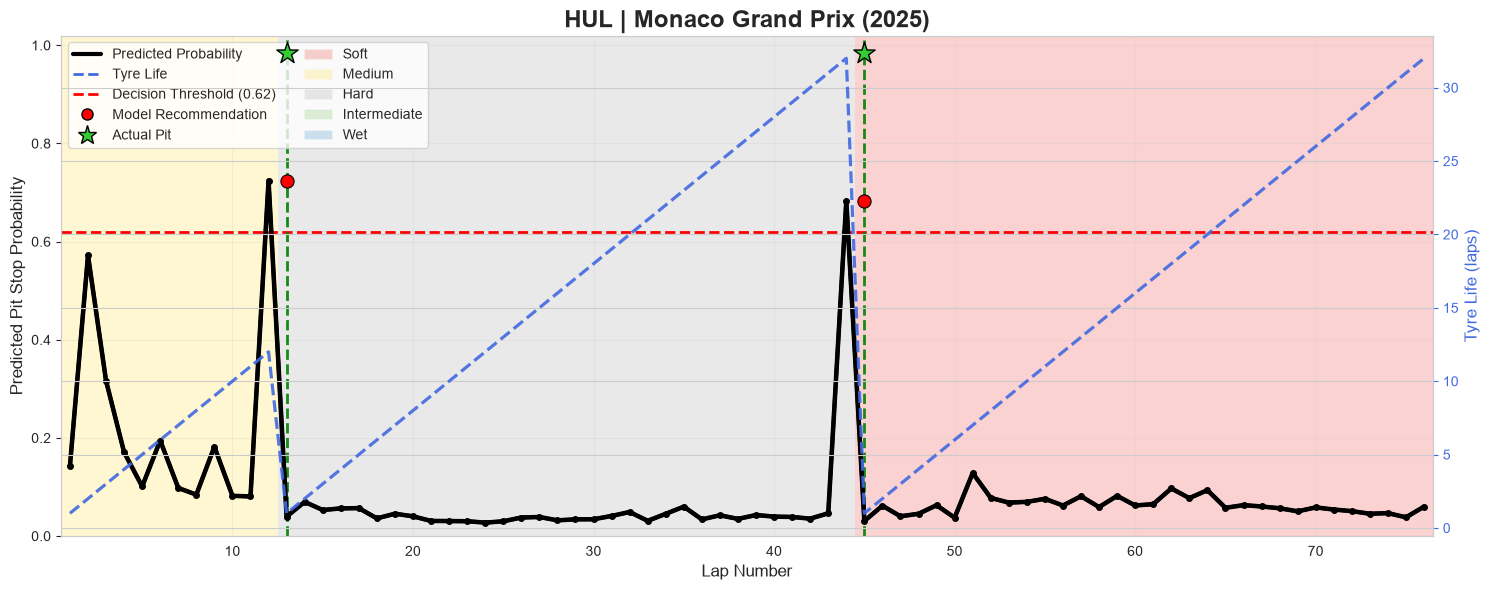

In [189]:
#Example 1: Perfect predictions
plot_pit_probability(test_df, test_probabilities, 2025, "Austrian Grand Prix", "RUS")
plot_pit_probability(test_df, test_probabilities, 2025, "Monaco Grand Prix", "HUL")

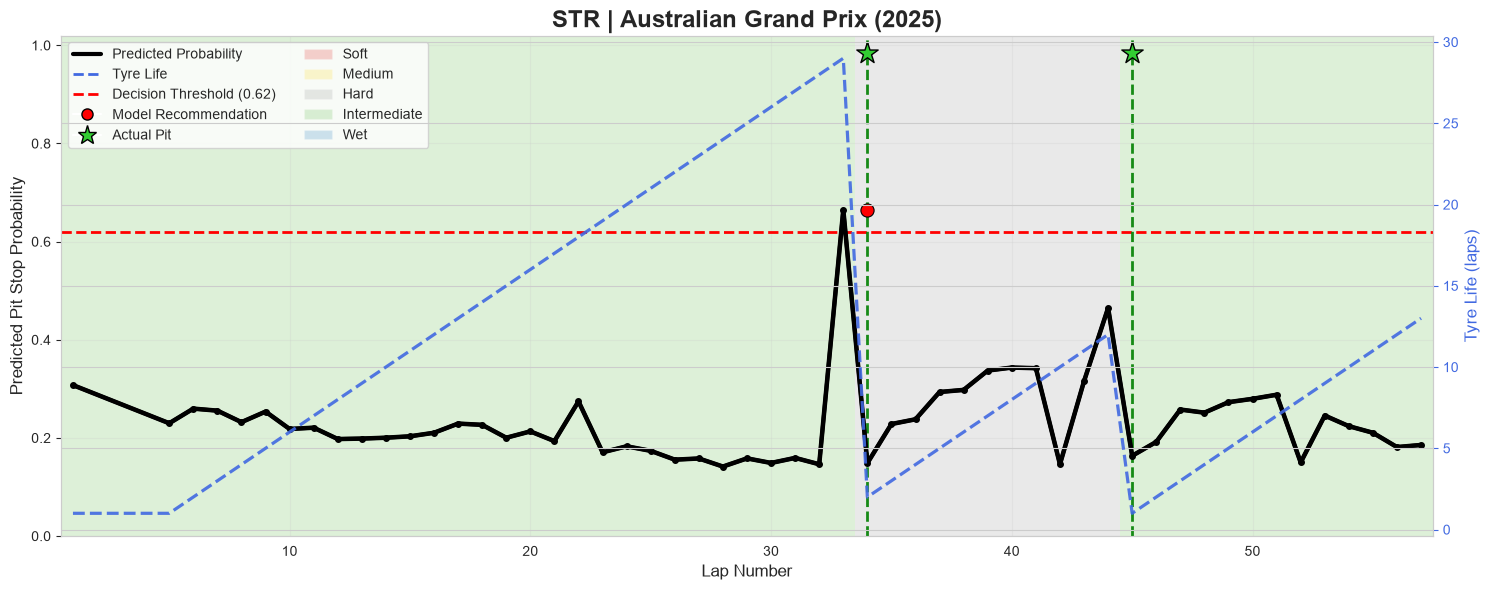

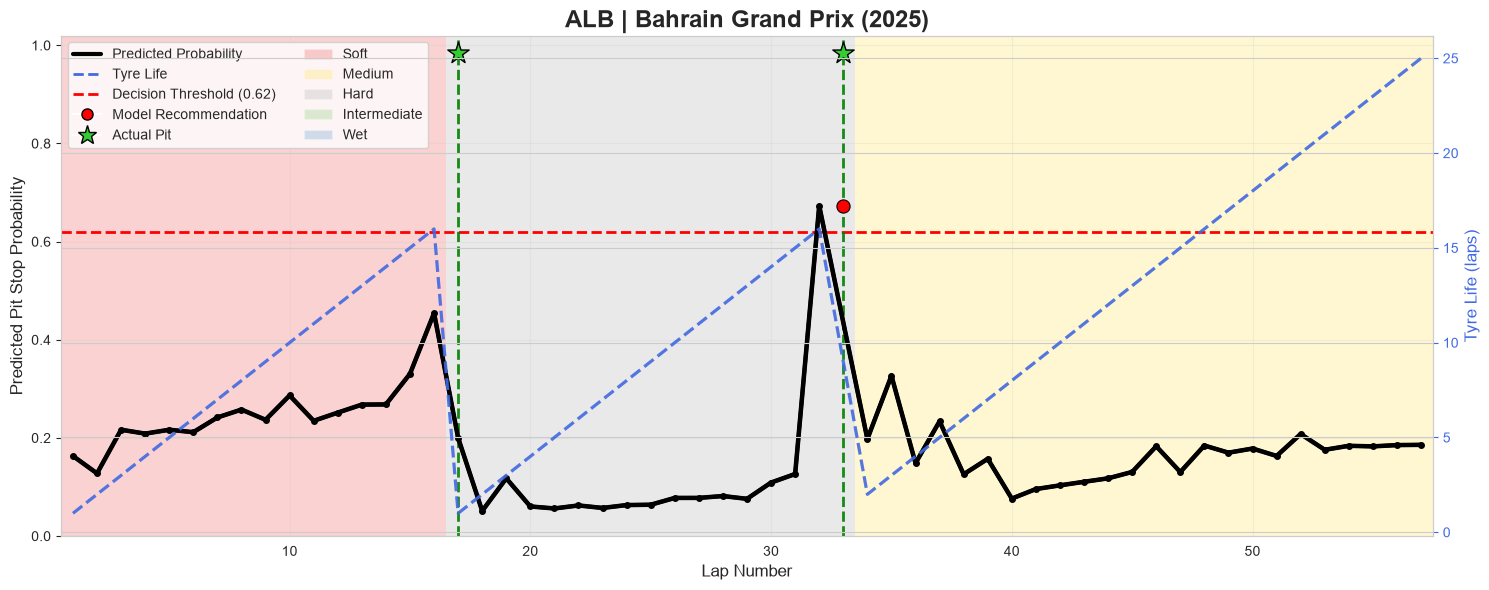

In [190]:
#Example 2: Almost-perfect predictions
plot_pit_probability(test_df, test_probabilities, 2025, "Australian Grand Prix", "STR")
plot_pit_probability(test_df, test_probabilities, 2025, "Bahrain Grand Prix", "ALB")

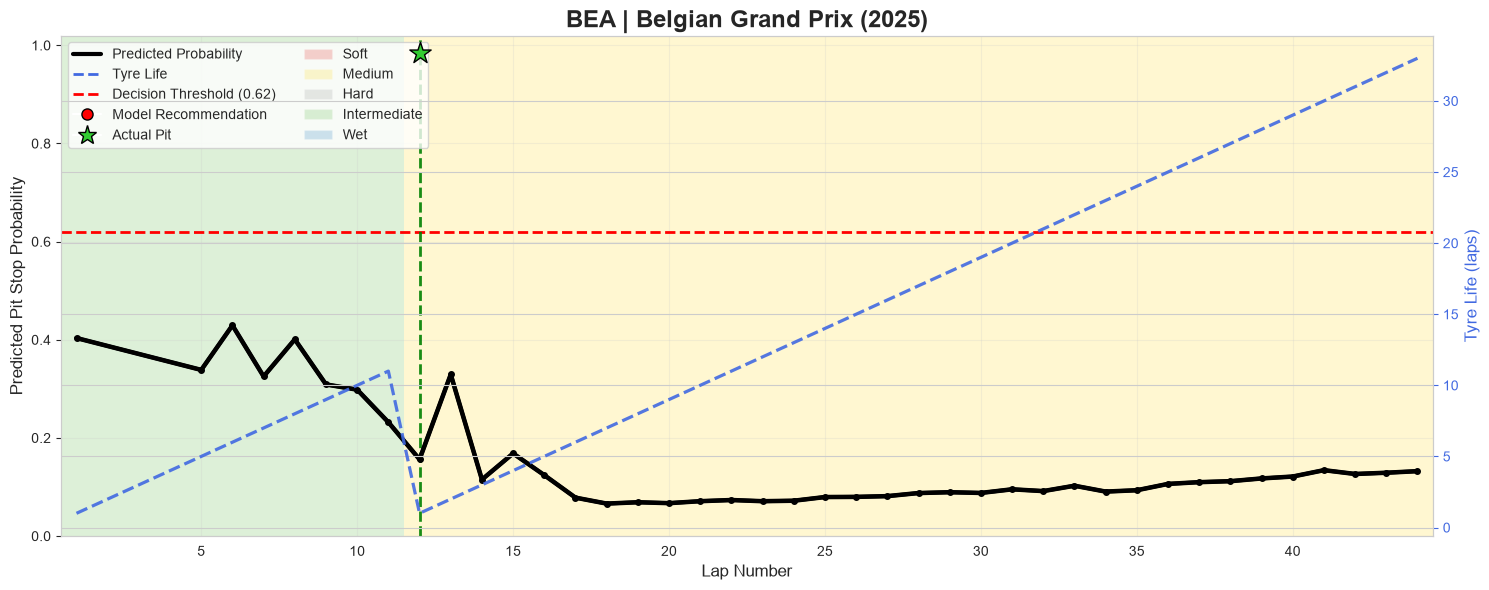

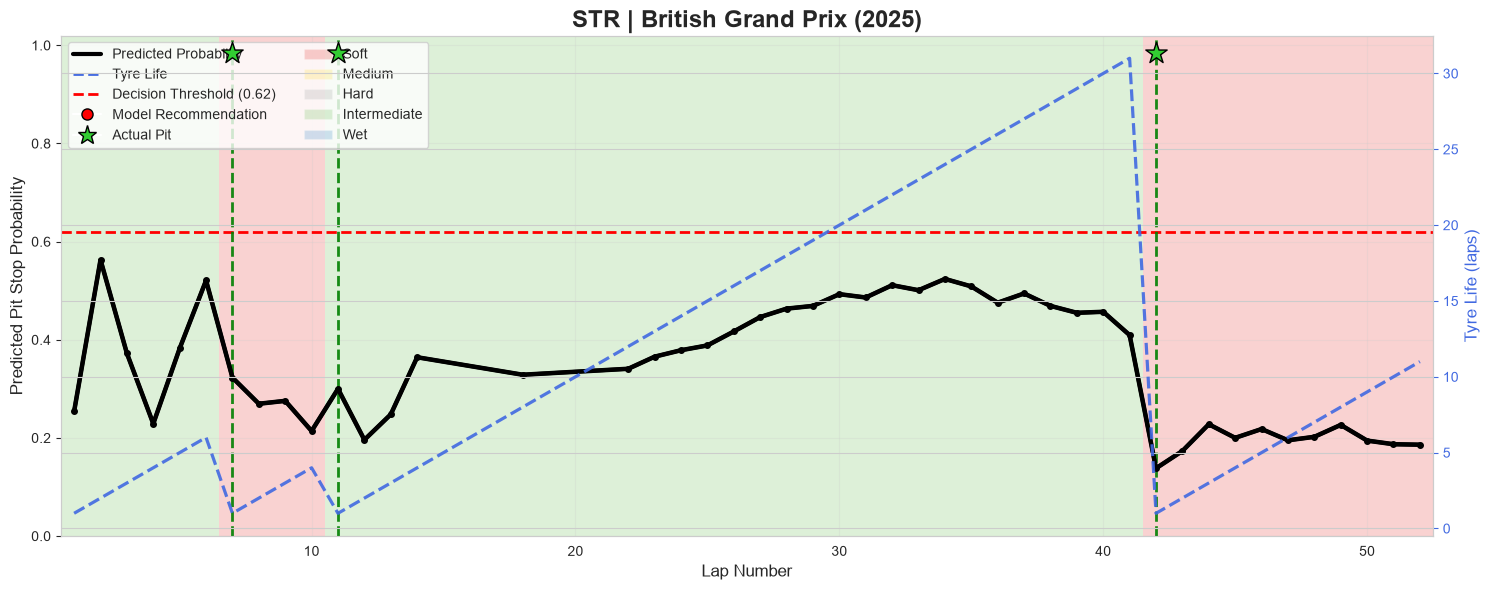

In [191]:
#Example 3: Completely missed
plot_pit_probability(test_df, test_probabilities, 2025, "Belgian Grand Prix", "BEA")
plot_pit_probability(test_df, test_probabilities, 2025, "British Grand Prix", "STR")